In [1]:
import pandas as pd
from scipy.io import arff
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from pathlib import Path
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix,ConfusionMatrixDisplay
import os
import numpy as np
from natsort import natsorted
import matplotlib.pyplot as plt

In [2]:
#obtendo datasets a serem testados
dir = "./hc-features/dataset20_index_features.csv"

dataset = pd.read_csv(dir,index_col=["y","x"])


#print(dataset)
#print(dataset["class"].value_counts())

X = dataset[["feature2", "feature5", "feature23", "feature27", "feature32", "feature34", "feature35", "feature45"]]

X.to_csv("teste.csv",index=False)

y = dataset["class"]

per_class_results = {} #armazena metricas por classe
results = {"acc":[],"f1":[]}#armazena metricas gerais 

kfold = StratifiedKFold(random_state=42,shuffle=True)

fold_errors = []
cm = np.zeros((len(dataset["class"].unique()),len(dataset["class"].unique())),dtype=int)
#print(cm.shape)
#4 folds used in test and 1 in training as described by Mailson
X_trains = []
X_tests = []
y_tests = []
for i, (test_index, train_index) in enumerate(kfold.split(X, y)):
    #treinamento e teste
    X_train = X.iloc[train_index]
    y_train = y.iloc[train_index]

    X_test = X.iloc[test_index]
    y_test = y.iloc[test_index]

    X_trains.append(X_train)
    X_tests.append(X_test)
    y_tests.append(y_test)

    #(y_train)
    
    scaler = StandardScaler()
    scaler = scaler.fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)

    model = SVC(kernel='rbf', C=1,random_state=42)
    model.fit(X_train, y_train)

    predicts = model.predict(X_test)

    errors_mask = (predicts != y_test)
    fold_errors.append(errors_mask)
    
    # Extraímos as informações apenas dessas amostras
    misclassified_samples = X_test[errors_mask]
    actual_labels = y_test[errors_mask]
    predicted_labels = predicts[errors_mask]
    #error_coordinates = c_test[errors_mask]

    
    #avaliacao geral
    accuracy = accuracy_score(y_test,predicts)
    f1 = f1_score(y_test,predicts,average="weighted")

    results["acc"].append(accuracy)
    results["f1"].append(f1) 

    #avaliacao por classe
    report = classification_report(y_test,predicts,output_dict=True,zero_division=0)
    
    for label, metrics in report.items():
        if label in ['accuracy', 'macro avg', 'weighted avg']:
            continue
        
        if label not in per_class_results:
            per_class_results[label] = {"precision": [], "recall": [], "f1-score": []}
        
        per_class_results[label]["precision"].append(metrics["precision"])
        per_class_results[label]["recall"].append(metrics["recall"])
        per_class_results[label]["f1-score"].append(metrics["f1-score"])

    #matriz de confusao
    cm += confusion_matrix(y_test,predicts)

#print(per_class_results)
#plottando matrizes de confusao
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)
disp.plot(ax=ax)
plt.title(f"Confusion matrix - hc features: dataset20")
image_name = f"cm_dataset20.png"
plt.savefig(image_name, dpi=300, bbox_inches='tight')
plt.close(fig)

#escrevendo metricas por classe
final_data = []


for label, metrics in per_class_results.items():
    final_data.append({
        "Dataset": "dataset20",
        "Class": label,
        "Prec_Mean": np.mean(metrics["precision"]),
        "Prec_Std": np.std(metrics["precision"]),
        "Recall_Mean": np.mean(metrics["recall"]),
        "Recall_Std": np.std(metrics["recall"]),
        "F1_Mean": np.mean(metrics["f1-score"]),
        "F1_Std": np.std(metrics["f1-score"])
    })


df_per_class_results = pd.DataFrame(final_data)
df_per_class_results.to_csv("metricas_por_classe_svm.csv", index=False, float_format="%.3f")

#escrevendo metricas gerais
final_data = []


final_data.append({
    "Dataset": "dataset20",
    "Acc_Mean": np.mean(results["acc"]),
    "Acc_Std": np.std(results["acc"]),
    "F1_Mean": np.mean(results["f1"]),
    "F1_Std": np.std(results["f1"])
})

# Criar DataFrame e salvar em CSV
df_results = pd.DataFrame(final_data)
df_results.to_csv("resultado_final_svm.csv", index=False, float_format="%.3f") 

In [3]:
import shutil

images_folder = Path("./images/dataset-20/")
save_dir = Path("./misclassified/dataset-20/")
images = os.listdir(images_folder)

coordinates = {}
already_saved_coordinates = set()
for img in images:
    name_parts = img.replace('.png', '').split('_')

    id_img, res, coord_y, coord_x, flag = name_parts

    coordinates[(int(coord_y),int(coord_x))] = os.path.join(images_folder,img)

for fold in fold_errors:
    coords = fold[fold==True].index
    for coord_tuple in coords:
        if coord_tuple not in already_saved_coordinates:
            already_saved_coordinates.add(coord_tuple)
            shutil.copy(coordinates[coord_tuple],save_dir)

print(f"{len(already_saved_coordinates)} images saved")
       

94 images saved


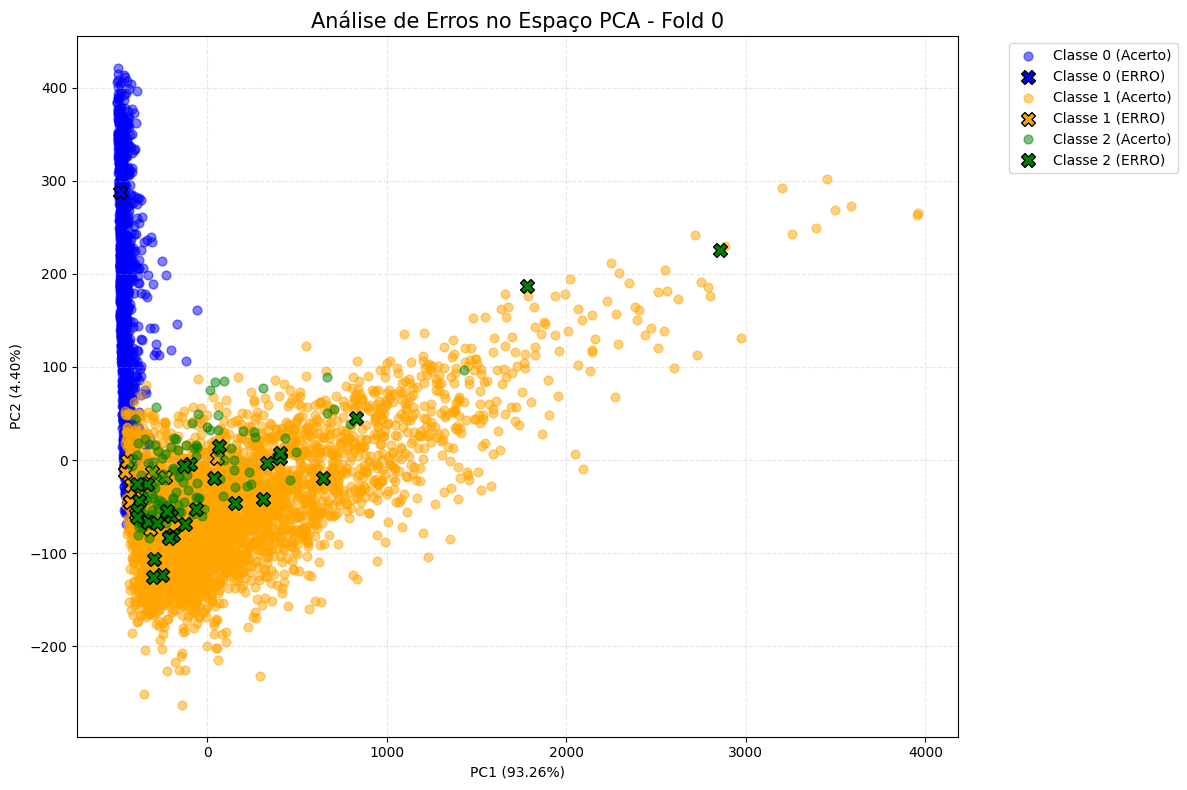

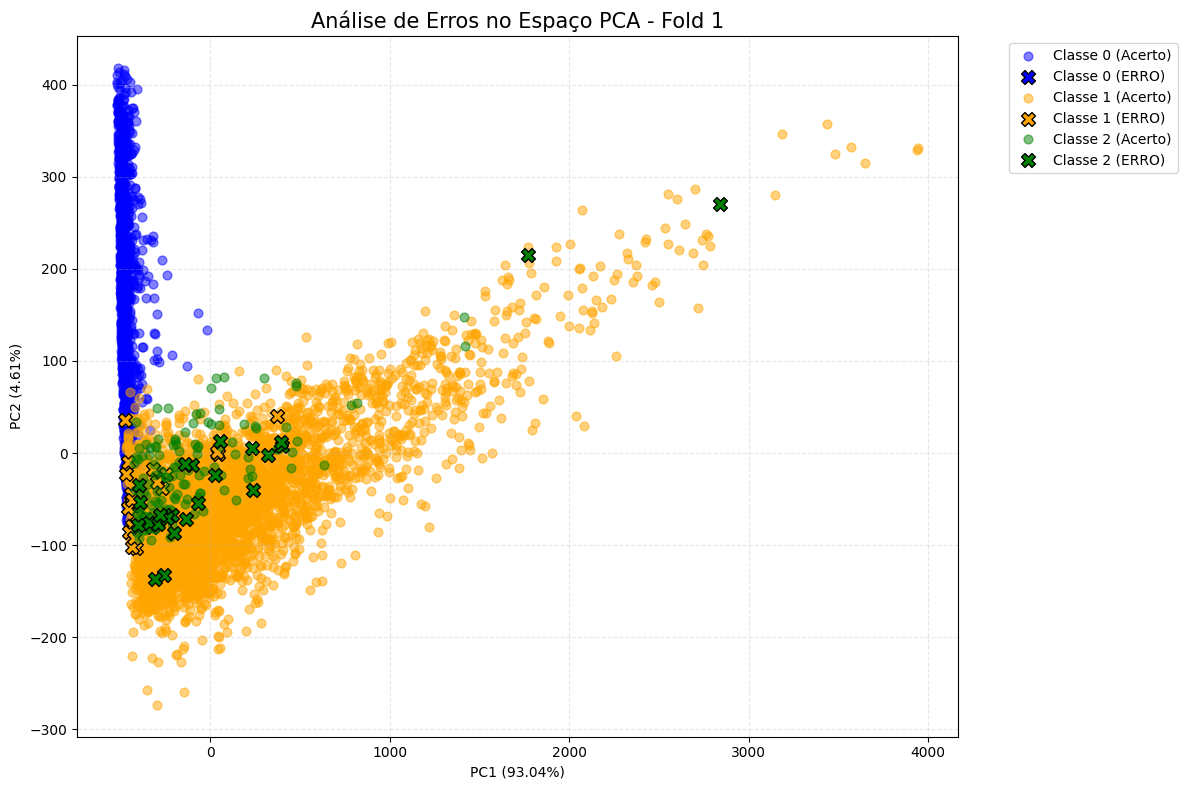

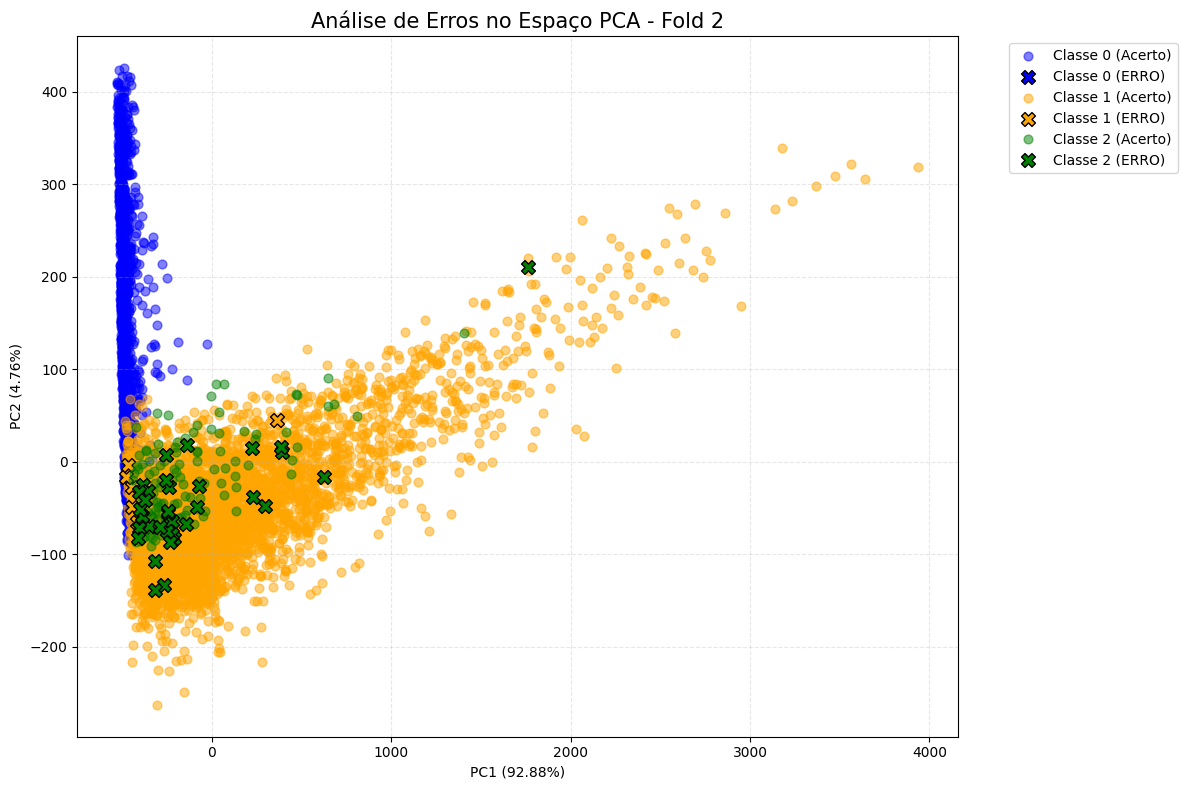

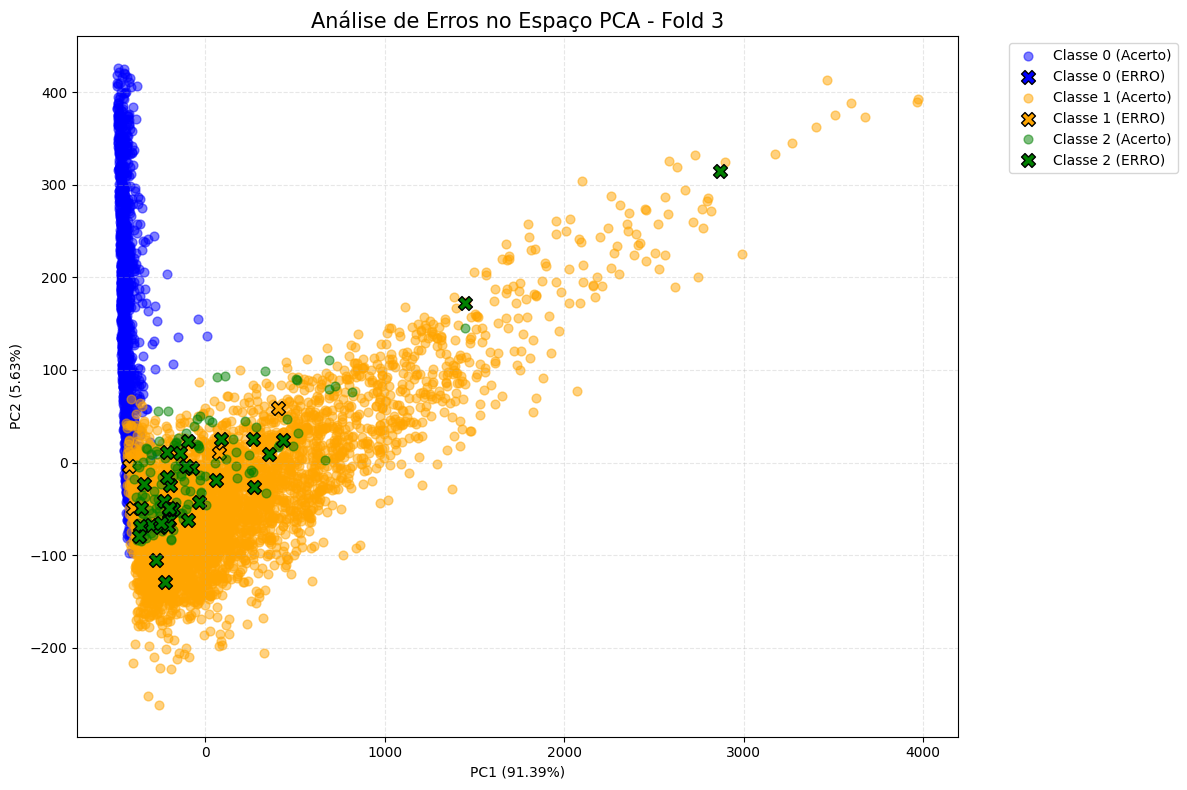

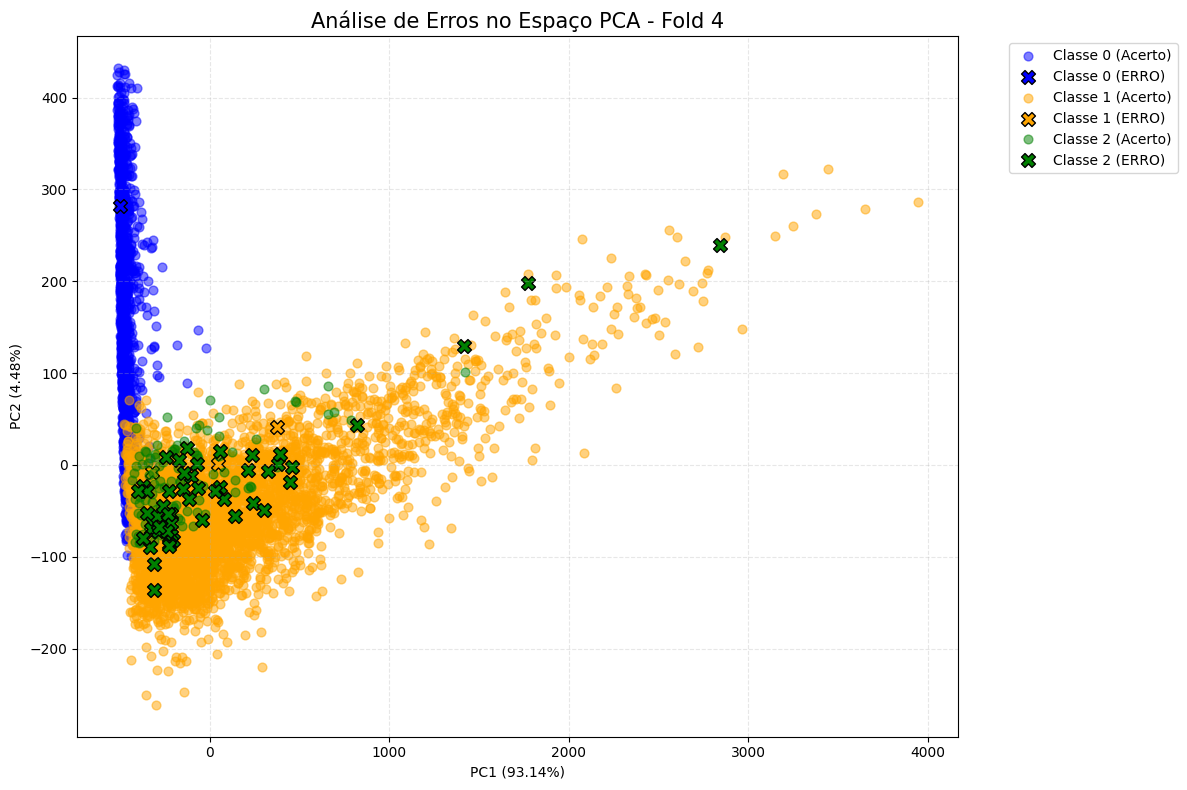

In [4]:

for i,(X_train,X_test,y_test,fold_error) in enumerate(zip(X_trains,X_tests,y_tests,fold_errors)):
    pca = PCA(random_state=42,n_components=2)
    pca = pca.fit(X_train)
    # 1. Redução de dimensionalidade (como você já fez)
    X_test_pca = pca.transform(X_test)

    fig, ax = plt.subplots(figsize=(12, 8))

    # Cores para cada classe
    cores_base = {0: 'blue', 1: 'orange', 2: 'green'}
    # Marcadores: 'o' para acertos, 'x' ou 'v' para erros
    marker_acerto = 'o'
    marker_erro = 'X' 

    # Iterar por cada classe (0, 1, 2)
    for classe in np.unique(y_test):
        # Máscara para a classe atual
        mask_classe = (y_test == classe)
        
        # Separar entre Acertos e Erros dentro desta classe
        # ~fold_errors significa "Não é erro" (Acerto)
        mask_acerto = mask_classe & ~np.array(fold_error)
        mask_erro = mask_classe & np.array(fold_error)
        
        # Plotar Acertos (Círculos coloridos)
        ax.scatter(
            X_test_pca[mask_acerto, 0], 
            X_test_pca[mask_acerto, 1], 
            c=cores_base[classe],
            label=f'Classe {classe} (Acerto)',
            marker=marker_acerto,
            alpha=0.5,
            s=40
        )
        
        # Plotar Erros (X com borda destacada)
        ax.scatter(
            X_test_pca[mask_erro, 0], 
            X_test_pca[mask_erro, 1], 
            c=cores_base[classe],
            label=f'Classe {classe} (ERRO)',
            marker=marker_erro,
            alpha=1.0,
            s=100,
            edgecolors='black', # Dá destaque ao erro
            linewidths=1
        )

    # Configurações do gráfico
    ax.set_title(f'Análise de Erros no Espaço PCA - Fold {i}', fontsize=15)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')

    # Coloca a legenda fora do gráfico para não obstruir os pontos
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

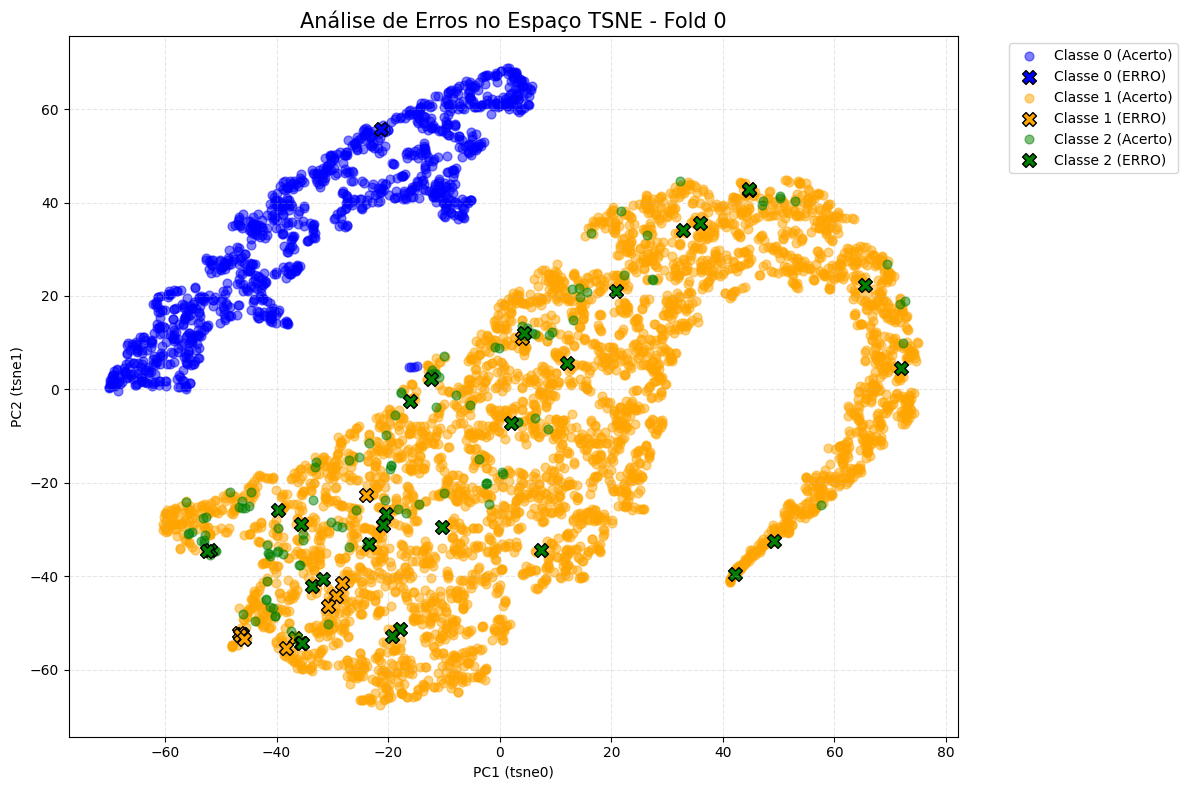

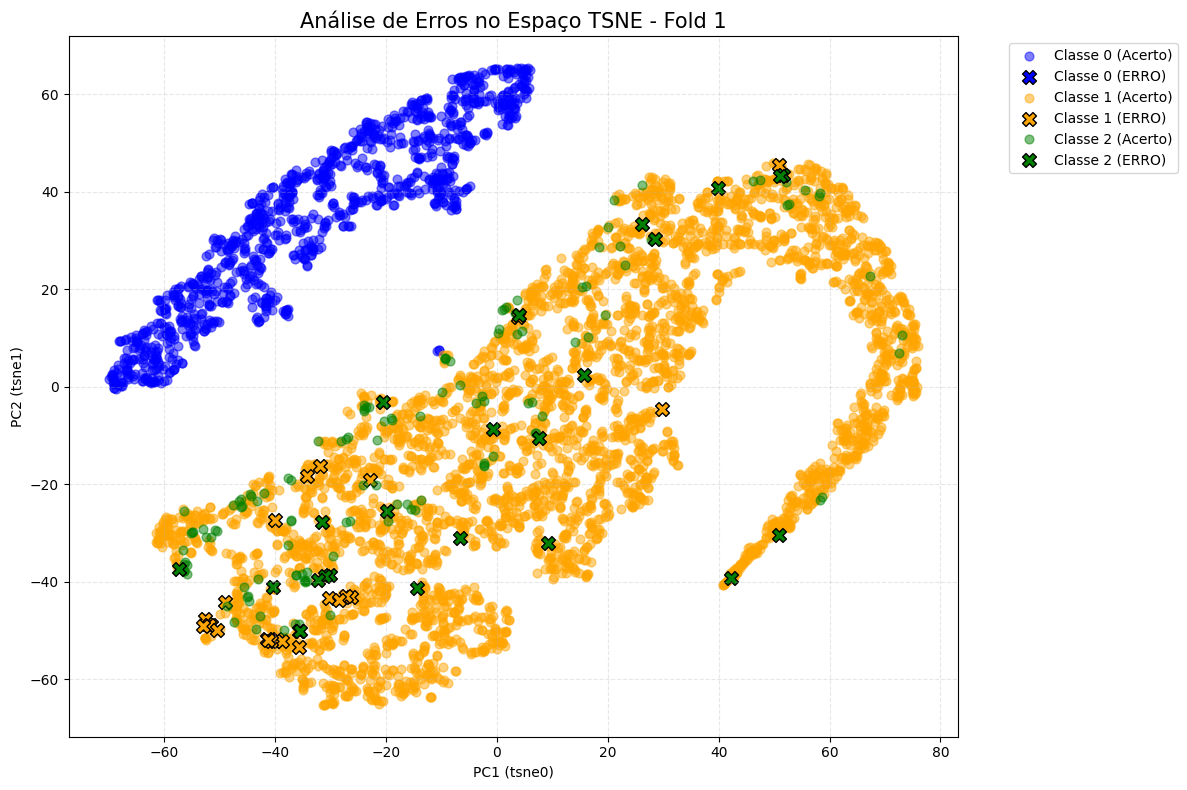

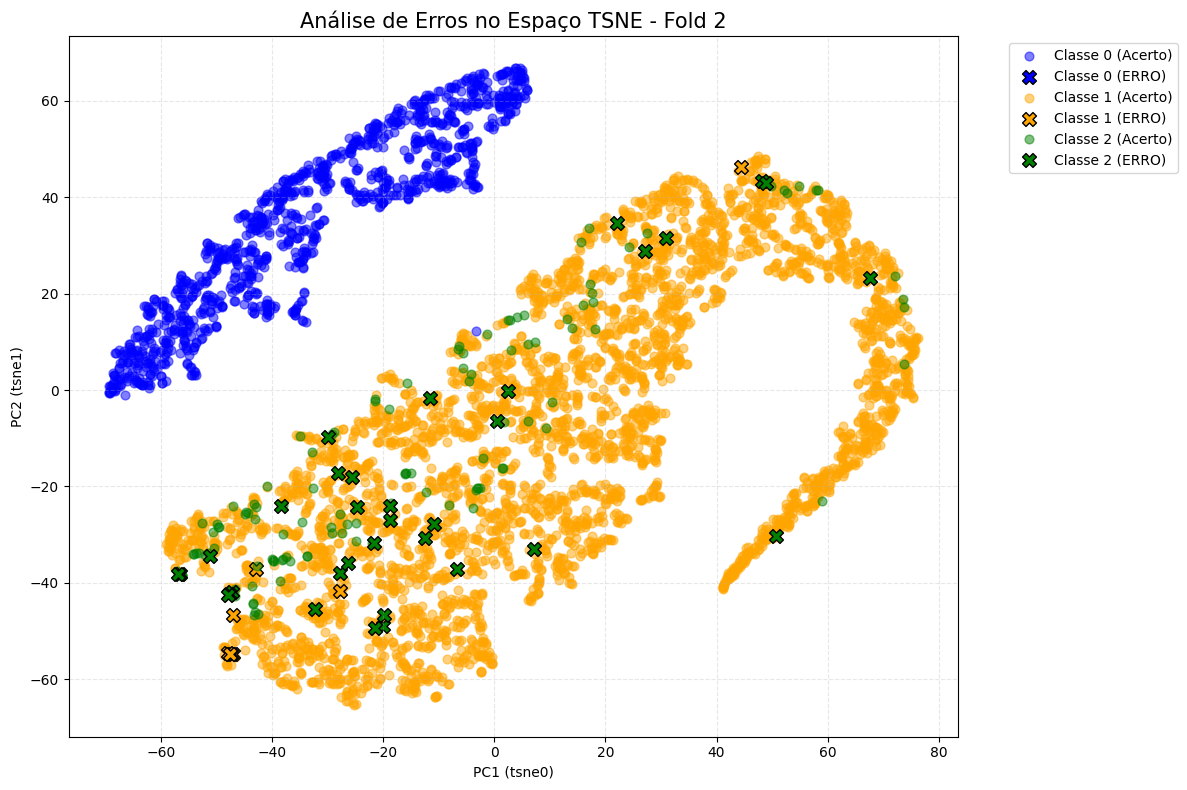

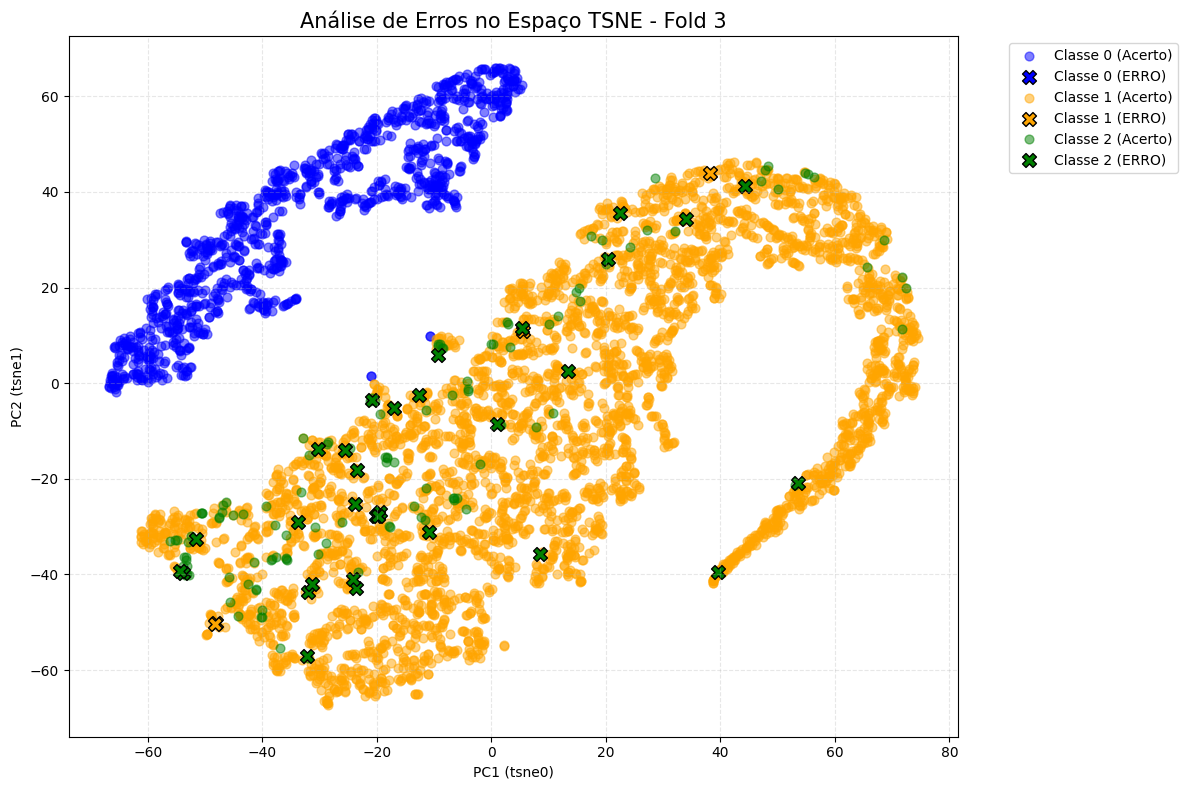

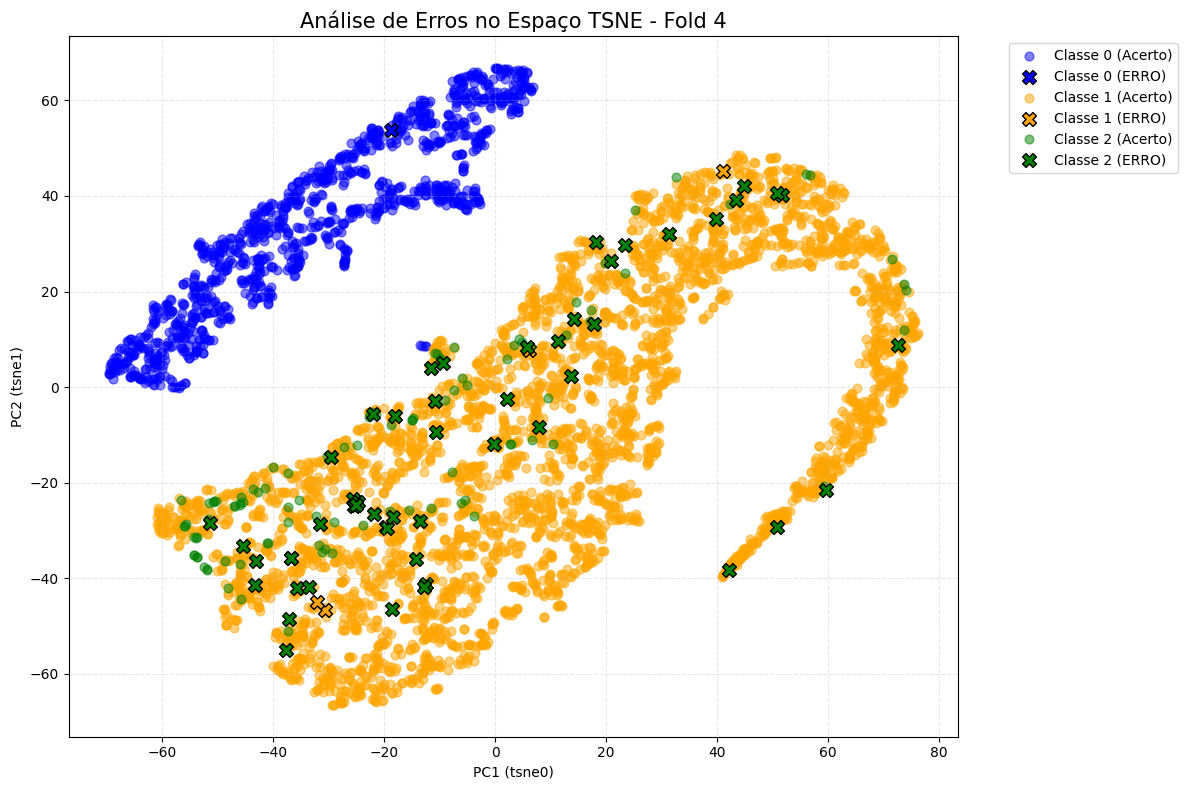

In [8]:

for i,(X_train,X_test,y_test,fold_error) in enumerate(zip(X_trains,X_tests,y_tests,fold_errors)):
    tsne = TSNE(random_state=42,n_components=2)
    
    # 1. Redução de dimensionalidade (como você já fez)
    X_test_tsne = tsne.fit_transform(X_test)

    fig, ax = plt.subplots(figsize=(12, 8))

    # Cores para cada classe
    cores_base = {0: 'blue', 1: 'orange', 2: 'green'}
    # Marcadores: 'o' para acertos, 'x' ou 'v' para erros
    marker_acerto = 'o'
    marker_erro = 'X' 

    # Iterar por cada classe (0, 1, 2)
    for classe in np.unique(y_test):
        # Máscara para a classe atual
        mask_classe = (y_test == classe)
        
        # Separar entre Acertos e Erros dentro desta classe
        # ~fold_errors significa "Não é erro" (Acerto)
        mask_acerto = mask_classe & ~np.array(fold_error)
        mask_erro = mask_classe & np.array(fold_error)
        
        # Plotar Acertos (Círculos coloridos)
        ax.scatter(
            X_test_tsne[mask_acerto, 0], 
            X_test_tsne[mask_acerto, 1], 
            c=cores_base[classe],
            label=f'Classe {classe} (Acerto)',
            marker=marker_acerto,
            alpha=0.5,
            s=40
        )
        
        # Plotar Erros (X com borda destacada)
        ax.scatter(
            X_test_tsne[mask_erro, 0], 
            X_test_tsne[mask_erro, 1], 
            c=cores_base[classe],
            label=f'Classe {classe} (ERRO)',
            marker=marker_erro,
            alpha=1.0,
            s=100,
            edgecolors='black', # Dá destaque ao erro
            linewidths=1
        )

    # Configurações do gráfico
    ax.set_title(f'Análise de Erros no Espaço TSNE - Fold {i}', fontsize=15)
    ax.set_xlabel(f'PC1 ({tsne.get_feature_names_out()[0]})')
    ax.set_ylabel(f'PC2 ({tsne.get_feature_names_out()[1]})')

    # Coloca a legenda fora do gráfico para não obstruir os pontos
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()